<a href="https://colab.research.google.com/github/pgordin/OptDisc2026/blob/main/projekt_kolorowanie_grafu_planarnego.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Projekt na podstawie książki "Graphs, Networks and Algorithms" autorstwa Dieter Jungnickel, rozdział 9.5 "Five colors theorem". Potem jednak zmieniłam na "proofs from the book".

In [ ]:
#Graf planarny to taki, który można narysować na płaszczyźnie tak, żeby krawędzie tego grafu nie przecinały się poza wierzchołkami.
#Oczywiście krawędzie nie muszą być liniami prostymi, ale ich ciągłość musi być zachowana. Przykładami grafów planarnych są cykle i drzewa.
#Kolorowanie grafów ma zastosowania praktyczne np. w alokacji zasobów i problemach optymalizacyjnych. Zastosowania te nie zostaną omówione w tym projekcie.

Algorytm
Dla danego grafu:

wybierany jest wierzchołek stopnia nie większego niż 5,
wierzchołek jest tymczasowo usuwany z grafu,
pozostały graf kolorowany jest rekurencyjnie,
usunięty wierzchołek dodawany jest z powrotem i otrzymuje pierwszy dostępny kolor spośród pięciu kolorów.

Import bibliotek

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from copy import deepcopy
from random import random

Klasa graph taka jak na zajęciach. Ponieważ kod jest długi to po kompilacji go zwinęłam. Konwersja do networkx jest kluczowa.

In [ ]:
# @title
class Graph:
    def __init__(self, graph=None):
        if graph is None:
            graph = {}
        self.graph = graph

    # inicjalizator ze słownika
    @classmethod
    def from_dict(cls, graph):
        return cls(graph)

    # inicjalizator z macierzy
    @classmethod
    def from_matrix(cls, matrix, vertices = None):
        if (vertices is None) or (len(vertices) != len(matrix)):
            vertices = [*range(1, len(matrix) + 1)]
        return cls.from_dict(cls._matrix_to_dict(matrix, vertices))

    # dwie prywatne metody macierz <-> słownik
    def _matrix_to_dict(matrix, vertices: list) -> dict:
        """
        Zamienia graf podany jako macierz sąsiedztwa na słownik sąsiedztwa.
        """
        res_dict = {}
        for i, v in enumerate(vertices):
            neighbours = [vertices[j] for j, edge in enumerate(matrix[i]) if edge]
            res_dict[v] = neighbours
        return res_dict

    def _dict_to_matrix(self, _dict: dict) -> np.array:
        """
        Zamienia graf podany jako słownik sąsiedztwa na macierz sąsiedztwa.
        """
        n = len(_dict)
        vertices = [*_dict.keys()]
        matrix = np.zeros(shape = (n, n), dtype=int)
        for u,v in [
            (vertices.index(u), vertices.index(v))
            for u, row in _dict.items() for v in row
        ]:
            matrix[u][v] += 1
        return matrix

    def vertices(self) -> list:
        """
        Zwraca listę wierzchołków grafu.
        """
        return [*self.graph.keys()]

    def matrix(self) -> np.array:
        """
        Zwraca macierz sąsiedztwa grafu.
        """
        return self._dict_to_matrix(self.graph)

    # przedefiniowania sposobu wyświetlania grafów
    def __str__(self):
        res = ""
        for v in self.graph:
            res += f"{v}:"
            for u in self.graph[v]:
                res += f" {u}"
            res += "\n"
        return res

    # Poniższe dostajemy za darmo z powyższego
    def to_neighbourlist(self, filename: str):
        """
        Zapisuje graf podany jako słownik (list) sąsiedztwa do pliku (w formie listy sąsiedztwa).
        Zmienna filename zawiera pełną ścieżkę pliku
        """
        file = open(filename, "w")  # otwarcie pliku tekstowego do zapisu
        file.write(str(self))
        file.close()

    # rysowanie grafów
    def plot(self, directed=0):
        """
        Rysuje graf używając metod biblioteki networkx.
        """
        if directed:
            G = nx.DiGraph(self.graph)
        else:
          G = nx.Graph(self.graph)
        pos = nx.spring_layout(G)
        nx.draw(G, pos, with_labels=True)
        plt.show()


    # Modyfikacje grafów
    def add_vertex(self, vertex):
        """
        Dodaje wierzchołek do grafu
        """
        if vertex not in self.graph:
            self.graph[vertex] = []

    def del_vertex(self, vertex):
        """
        Usuwa wierzchołek z grafu
        """
        if vertex in self.graph:
            self.graph.pop(vertex)
            for u in self.graph:
                if vertex in self.graph[u]:
                    self.graph[u].remove(vertex)

    def add_arc(self, arc):
        """
        Dodaje łuk (skierowany, podany jako para wierzchołków) do grafu
        """
        u, v = arc
        self.add_vertex(u)
        self.add_vertex(v)
        if v not in self.graph[u]:
            self.graph[u].append(v)

    def add_edge(self, edge: list):
        """
        Dodaje krawędź (podaną jako para wierzchołków) do grafu
        Rozpatrujemy grafy proste, nieskierowane
        """
        u, v = edge
        if u == v:
            raise ValueError("Pętle nie są dopuszczalne!")
        self.add_vertex(u)
        self.add_vertex(v)
        if v not in self.graph[u]:
            self.graph[u].append(v)
        if u not in self.graph[v]:
            self.graph[v].append(u)

    # czytanie z plików
    @staticmethod
    def from_edges(filename: str, directed = 0):
        """
        Tworzy graf na podstawie pliku z łukami/krawędziami.
        Opis łuku/krawędzi to dwa słowa lub wierzchołka (jedno słowo).
        Nadmiarowe słowa są ignorowane.
        Zmienna filename zawiera pełną ścieżkę pliku
        """
        graph = Graph()
        file = open(filename, "r")          # otwarcie pliku do odczytu
        for line in file:                   # dla każdej linii w pliku
          words = line.strip().split()      # rozdziel linię na słowa
          if len(words) == 1:               # jedno słowo - opis wierzchołka
            graph.add_vertex(words[0])
          elif len(words) >= 2:             # conajmnej 2 słowa - opis krawędzi/łuku
            if directed:
              graph.add_arc([words[0], words[1]])
            else:
              graph.add_edge([words[0], words[1]])
        file.close()
        return graph

    def to_edges(self, filename, directed=1):
      """
      Zapisuje graf podany jako słownik (list) sąsiedztwa do pliku (w formie listy krawędzi).
      Zapis jako grafd skierowany lub nieskierowany zależy od wartości zmiennej directed.
      Zmienna filename zawiera pełną ścieżkę pliku
      """
      with open(filename,"w") as file:
        wierzcholki = list(self.graph.keys())
        for v in self.graph:
          if len(self.graph[v]) > 0:
            for u in self.graph[v]:
              if ((directed) or (wierzcholki.index(v) < wierzcholki.index(u))):
                line = f"{v} {u}\n"
                file.write(line)
          else:
                file.write(v + "\n")

    @staticmethod
    def from_neighbourlist(filename, directed=0):
      """
      Tworzy graf na podstawie pliku z listą sąsiedztwa.
      Zmienna filename zawiera pełną ścieżkę pliku
      """
      graph = Graph()
      with open(filename, 'r') as file:
        for line in file:
          line = line.replace(":", "")
          words = list(line.strip().split())
          graph.add_vertex(words[0])
          for i in range(1,len(words)):
            if directed:
              graph.add_arc((words[0],words[i]))
            else:
              graph.add_edge((words[0],words[i]))
      return graph

    @staticmethod
    def random_graph(n: int, p: float):
        """
        Tworzy losowy graf nieskierowany G(n,p)
        """
        rand_graph = Graph()
        for i in range(1, n + 1):
            rand_graph.add_vertex(i)
            for j in range(1, i):
                if random() < p:
                    rand_graph.add_edge([i, j])
        return rand_graph

    @staticmethod
    def cycle(n: int):
        """
        Tworzy graf cykliczny o n wierzchołkach
        """
        cycle = Graph()
        for i in range(n-1):
          cycle.add_edge([i+1, i+2])
        cycle.add_edge([1, n])
        return cycle

    def Prufer(self):
        """
        Zwraca kod Prüfera drzewa.
        Nie jest sprawdzane, czy graf jest drzewem. Dla nie drzew może działać źle.
        Wynik podany jako napis (pusty gdy jest mniej niż 3 wierzchołki).
        """
        tr = deepcopy(self.graph)   # kopia słownika grafu
        code = ""
        for i in range(len(self.graph)-2):
          for x in sorted(tr):
            if len(tr[x])==1:     # najmniejszy liść
              break
          v = tr[x][0]            # sąsiad najmniejszego liścia
          code += f"{v} "
          tr.pop(x)
          tr[v].remove(x)
        return code.strip()

    @staticmethod
    def tree_from_Prufer(code :str):
      """
      Tworzy drzewo z kodu Prüfera
      """
      tree = Graph()
      clist = [int(x) for x in code.strip().split()]  # kod jako lista liczb
      n = len(clist) + 2    # liczba wierzchołków
      vert = [*range(1, n + 1)]
      for v in vert:
        tree.add_vertex(v)
      for i in range(n-2):
        for x in vert:
          if x not in clist:    # najmniejszy liść
            break
        v = clist.pop(0)  # sąsiad najmniejszego liścia
        tree.add_edge([x, v])
        vert.remove(x)
      tree.add_edge(vert) # na liście vert zostały 2 elementy - ostatnia krawędź
      return tree











      #praca domowa
    def preorder(self, v, visited=None):
      if visited is None:
          visited = set()

      visited.add(v)
      print(v, end=" ")

      for u in self.graph[v]:
          if u not in visited:
              self.preorder(u, visited)
    def postorder(self, v, visited=None):
      if visited is None:
         visited = set()

      visited.add(v)

      for u in self.graph[v]:
        if u not in visited:
           self.postorder(u, visited)

      print(v, end=" ")

     #graf losowy dwudzielny może być bardzo różny i niespójny
    @staticmethod
    def random_bipartite_graph(n: int, p: float):
      #pusty graf
      g = Graph()

    # podział na dwie grafy
      A = list(range(1, n + 1))
      B = list(range(n + 1, 2*n + 1))

    # wierzchołki
      for v in A + B:
         g.add_vertex(v)

    # losowe krawędzie
      for u in A:
        for v in B:
          if random() < p:
               g.add_edge([u, v])

      return g


      #część 5
    def ConnectedComponentsBFS(self):

        #Zwraca listę spójnych składowych grafu wykorzystując BFS.


        visited = set()
        components = []

        for v in self.graph:
            if v not in visited:

                component = set([v])
                visited.add(v)

                queue = [v]

                while queue:
                    u = queue.pop(0)

                    for w in self.graph[u]:
                        if w not in visited:
                            visited.add(w)
                            component.add(w)
                            queue.append(w)

                components.append(component)

        return components

    def TopologicalSort(self):

        #Sortowanie topologiczne grafu skierowanego.


        visited = set()
        result = []

        def DFS(v):
            visited.add(v)

            for u in self.graph[v]:
                if u not in visited:
                    DFS(u)

            result.append(v)

        for v in self.graph:
            if v not in visited:
                DFS(v)

        result.reverse()
        return result

    def StronglyConnectedComponents(self):
        """
        Zwraca silnie spójne składowe grafu skierowanego.
        Algorytm Kosaraju.
        """

        visited = set()
        order = []

        # pierwszy DFS
        def DFS1(v):
            visited.add(v)

            for u in self.graph[v]:
                if u not in visited:
                    DFS1(u)

            order.append(v)

        for v in self.graph:
            if v not in visited:
                DFS1(v)

        # odwrócenie grafu
        reversed_graph = Graph()

        for v in self.graph:
            reversed_graph.add_vertex(v)

        for v in self.graph:
            for u in self.graph[v]:
                reversed_graph.add_arc((u, v))

        # drugi DFS
        visited.clear()
        components = []

        def DFS2(v, component):
            visited.add(v)
            component.append(v)

            for u in reversed_graph.graph[v]:
                if u not in visited:
                    DFS2(u, component)

        while order:
            v = order.pop()

            if v not in visited:
                component = []
                DFS2(v, component)
                components.append(component)

        return components
    def degree(self, v):
        return len(self.graph[v])
    def del_edge(self, edge):
        u, v = edge

        if v in self.graph[u]:
            self.graph[u].remove(v)

        if u in self.graph[v]:
            self.graph[v].remove(u)
    def copy(self):
        return Graph(deepcopy(self.graph))
    def to_networkx(self):
        G = nx.Graph()

        for v in self.graph:
            G.add_node(v)

        for v in self.graph:
            for u in self.graph[v]:
                G.add_edge(v, u)

        return G
    @staticmethod
    def grid(m, n):
        g = Graph()
        for i in range(m):
            for j in range(n):
                v = (i, j)
                g.add_vertex(v)
                # połączenie w dół
                if i > 0:
                    g.add_edge(((i-1, j), v))
                # połączenie w lewo
                if j > 0:
                    g.add_edge(((i, j-1), v))
        return g

Test planarności. Algorytm działa tylko na grafach planarnych. Na szczęście jest gotowa funkcja do sprawdzania planarności.


In [ ]:
def is_planar(graph):
    G_nx = graph.to_networkx()

    planar, embedding = nx.check_planarity(G_nx)

    return planar

In [ ]:
g = Graph.cycle(5)

print(is_planar(g))

True


In [ ]:
def kolorowanie(graph):

    # pusty graf
    if len(graph.vertices()) == 0:
        return {}

    # znajdź wierzchołek stopnia <= 5
    for v in graph.vertices():
        if graph.degree(v) <= 5:
            chosen = v
            break

    # kopia grafu
    smaller = graph.copy()

    # sąsiedzi
    neighbours = smaller.graph[chosen][:]

    # usuń wierzchołek
    smaller.del_vertex(chosen)

    # rekurencja
    coloring = kolorowanie(smaller)

    # użyte kolory
    used = set()

    for u in neighbours:
        if u in coloring:
            used.add(coloring[u])

    # znajdź wolny kolor
    for color in range(5):

        if color not in used:
            coloring[chosen] = color
            return coloring

    # teoretycznie nie powinno się zdarzyć
    raise Exception("Nie udało się pokolorować grafu")

Funkcja do rysowania grafu.

In [ ]:
def rysuj(graph, coloring):

    G = graph.to_networkx()

    color_map = []
#lista kolorów można ją zmieniać w zależności od preferencji
    colors = [
        "#e04764",
        "#10dae6",
        "#4e9c3a",
        "#dc7cfa",
        "#ffdc00"
    ]

    for v in G.nodes():
        color_map.append(colors[coloring[v]])

    pos = nx.planar_layout(G)

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_color=color_map,
        node_size=800
    )

    plt.show()

Test algorytmu

{17: 0, 16: 1, 15: 0, 14: 1, 13: 0, 12: 1, 11: 0, 10: 1, 9: 0, 8: 1, 7: 0, 6: 1, 5: 0, 4: 1, 3: 0, 2: 1, 1: 2}


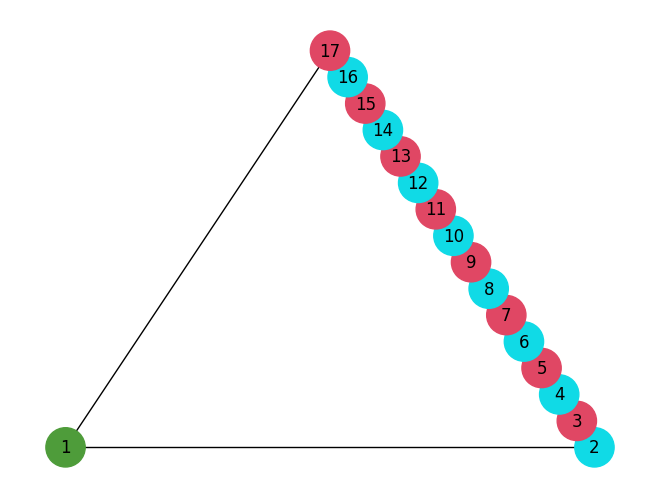

In [ ]:
g = Graph.cycle(17)

pokolorowany = kolorowanie(g)

print(pokolorowany)

rysuj(g, pokolorowany)

Sprawdzanie poprawności kolorowania, gdyby graf był za duży do sprawdzenia ręcznego.

In [ ]:
def check_coloring(graph, coloring):

    for v in graph.graph:
        for u in graph.graph[v]:

            if coloring[v] == coloring[u]:
                return False

    return True

In [ ]:
print(check_coloring(g, pokolorowany))

True


Liczba użytych kolorów

In [ ]:
def number_of_colors(coloring):
    return len(set(coloring.values()))

In [ ]:
print(number_of_colors(pokolorowany))

3


Siatka

True
{(3, 3): 0, (3, 2): 1, (3, 1): 0, (3, 0): 1, (2, 3): 1, (2, 2): 0, (2, 1): 1, (2, 0): 0, (1, 3): 0, (1, 2): 1, (1, 1): 0, (1, 0): 1, (0, 3): 1, (0, 2): 0, (0, 1): 1, (0, 0): 0}


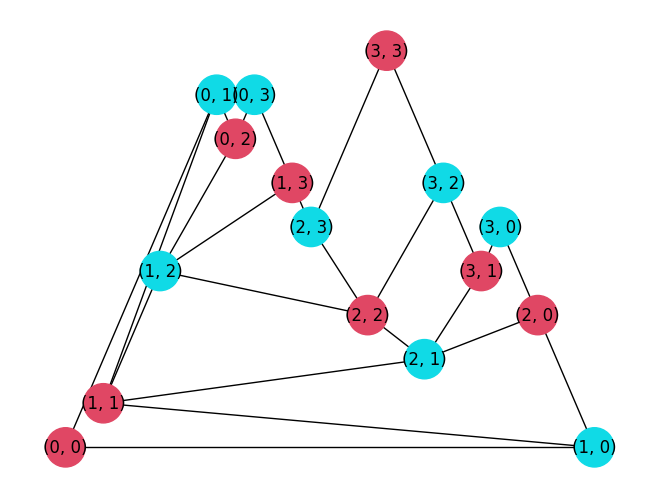

In [ ]:
g = Graph.grid(4,4)

print(is_planar(g))

coloring = kolorowanie(g)

print(coloring)

rysuj(g, coloring)

Graf losowy planarny

In [ ]:
def random_planar_graph(n, p=0.3):

    while True:

        g = Graph.random_graph(n, p)

        if is_planar(g):
            return g

True
{10: 0, 9: 0, 8: 1, 7: 1, 6: 1, 5: 0, 4: 2, 3: 2, 2: 0, 1: 3}


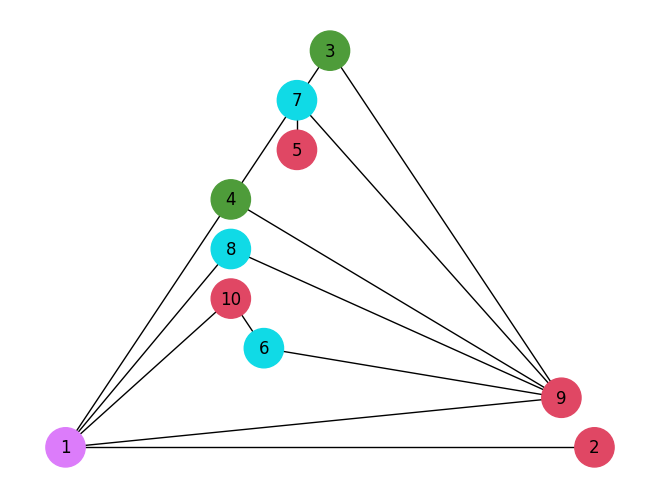

In [ ]:
g = random_planar_graph(10, 0.3)

print(is_planar(g))

coloring = kolorowanie(g)

print(coloring)

rysuj(g, coloring)